(14116, 28)
Media: 25.54
Mediana: 23.0
Moda: 19
Percentil 25: 21.0
Percentil 50: 23.0
Percentil 75: 28.0
Edad mínima: 18
Edad máxima: 75

--- Tabla de Frecuencias por Intervalos de Edad (15 intervalos) ---
   Intervalo de Edad  Frecuencia Absoluta (fi)  Frecuencia Relativa (hi)  \
0       (17.0, 22.0]                      4793                  0.339544   
1       (22.0, 26.0]                      4567                  0.323534   
2       (26.0, 29.0]                      2014                  0.142675   
3       (29.0, 33.0]                       832                  0.058940   
4       (33.0, 37.0]                       692                  0.049022   
5       (37.0, 41.0]                       364                  0.025786   
6       (41.0, 45.0]                       342                  0.024228   
7       (45.0, 48.0]                       243                  0.017215   
8       (48.0, 52.0]                       155                  0.010980   
9       (52.0, 56.0]              

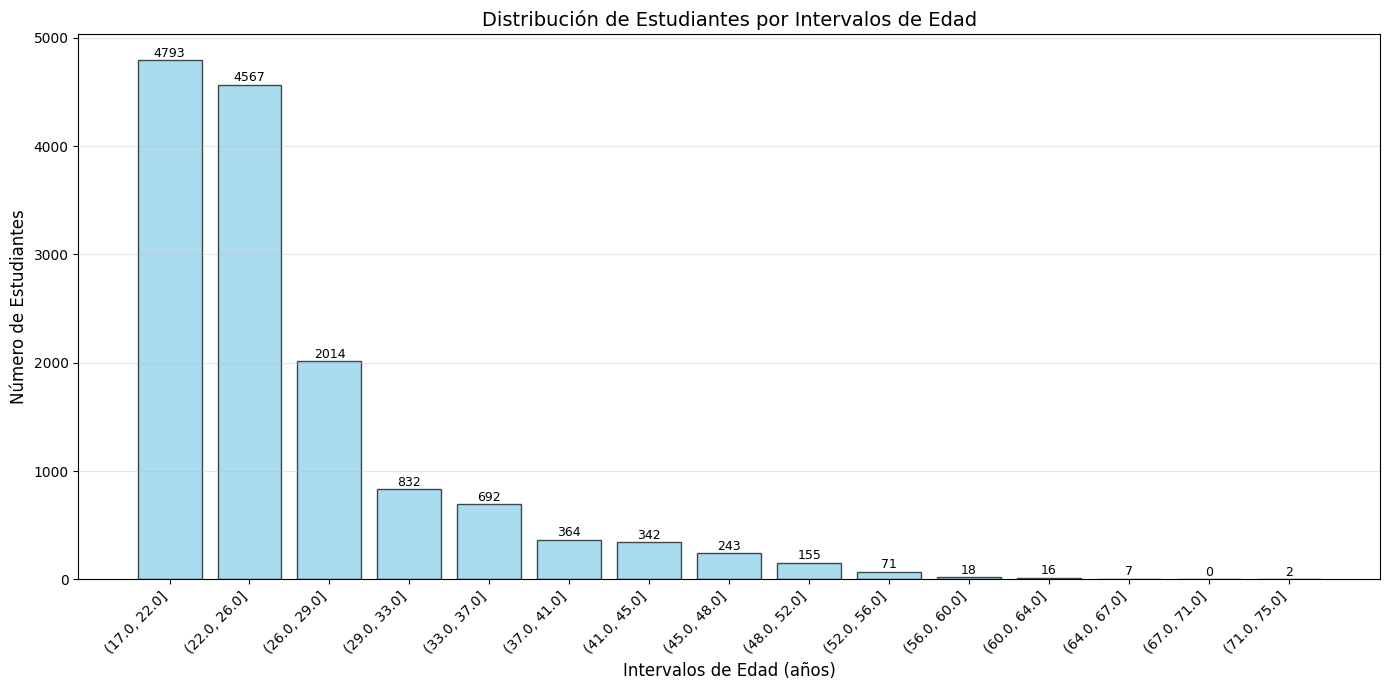

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('01_MATRICULAS_ED_SUPERIOR_ARICA_Y_PARINACOTA_2021.xlsx')

edad = df['EDAD'].dropna()
media = edad.mean().round(2)
mediana = edad.median()
moda = edad.mode().iloc[0]

print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Moda: {moda}')

percentil_25 = edad.quantile(0.25)
percentil_50 = edad.quantile(0.50)
percentil_75 = edad.quantile(0.75)

print(f'Percentil 25: {percentil_25}')
print(f'Percentil 50: {percentil_50}')
print(f'Percentil 75: {percentil_75}')

minimo = edad.min()
maximo = edad.max()
print(f'Edad mínima: {minimo}')
print(f'Edad máxima: {maximo}')

num_bins = 15
edad_intervalos = pd.cut(edad, bins=num_bins, precision=0, include_lowest=True)

frecuencia_absoluta_intervalos = edad_intervalos.value_counts().sort_index()

tabla_frecuencia_intervalos = pd.DataFrame({
    'Intervalo de Edad': frecuencia_absoluta_intervalos.index.astype(str),
    'Frecuencia Absoluta (fi)': frecuencia_absoluta_intervalos.values
})

total_estudiantes = len(edad)
tabla_frecuencia_intervalos['Frecuencia Relativa (hi)'] = (
    tabla_frecuencia_intervalos['Frecuencia Absoluta (fi)'] / total_estudiantes
)
tabla_frecuencia_intervalos['Porcentaje (%)'] = (
    tabla_frecuencia_intervalos['Frecuencia Relativa (hi)'] * 100
).round(2)

tabla_frecuencia_intervalos['Frecuencia Acumulada (Fi)'] = (
    tabla_frecuencia_intervalos['Frecuencia Absoluta (fi)'].cumsum()
)

print("\n--- Tabla de Frecuencias por Intervalos de Edad (15 intervalos) ---")
print(tabla_frecuencia_intervalos)

plt.figure(figsize=(14, 7))

plt.bar(
    tabla_frecuencia_intervalos['Intervalo de Edad'],
    tabla_frecuencia_intervalos['Frecuencia Absoluta (fi)'],
    color='skyblue',
    edgecolor='black',
    alpha=0.7
)

plt.xlabel('Intervalos de Edad (años)', fontsize=12)
plt.ylabel('Número de Estudiantes', fontsize=12)
plt.title('Distribución de Estudiantes por Intervalos de Edad', fontsize=14)

plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(tabla_frecuencia_intervalos['Frecuencia Absoluta (fi)']):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('01_MATRICULAS_ED_SUPERIOR_ARICA_Y_PARINACOTA_2021.xlsx')

def sturges(n):
    return int(1 + 3.322 * np.log10(n))

df['ARANCEL'] = df['VALOR ARANCEL (PESOS)']

media = df['ARANCEL'].mean().round(2)
mediana = df['ARANCEL'].median()
moda = df['ARANCEL'].mode().iloc[0]

percentil_25 = df['ARANCEL'].quantile(0.25)
percentil_50 = df['ARANCEL'].quantile(0.50)
percentil_75 = df['ARANCEL'].quantile(0.75)

print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Moda: {moda}')
print(f'Percentil 25: {percentil_25}')
print(f'Percentil 50: {percentil_50}')
print(f'Percentil 75: {percentil_75}')

minimo = df['ARANCEL'].min()
maximo = df['ARANCEL'].max()
print(f'Arancel mínimo: {minimo}')
print(f'Arancel máximo: {maximo}')

n = df.shape[0]
k = sturges(n)
print(f'\nNúmero de intervalos según Sturges: {k}')

minimo = int(df['ARANCEL'].min())
maximo = int(df['ARANCEL'].max())
limites = np.linspace(minimo, maximo, k + 1, dtype=int)
df['Intervalos'] = pd.cut(df['ARANCEL'], bins=limites, include_lowest=True)

frecuencia = df.groupby('Intervalos', observed=True).size()

tabla_continua = pd.DataFrame({
    'fi': frecuencia,
    'hi': (frecuencia/n)*100,
    'Fi': frecuencia.cumsum(),
    'Hi': ((frecuencia/n) * 100).cumsum()
})

print('\n--- Tabla de Frecuencias por Intervalos de Arancel ---')
print(tabla_continua.round(2))

fig, ax = plt.subplots(figsize=(14, 7))
histograma = ax.bar(tabla_continua.index.astype(str), tabla_continua['fi'], color='lightgreen', edgecolor='black', width=1)

ax.set_title(f'Distribución de Estudiantes por Arancel ({k} intervalos)', fontsize=14)
ax.set_xlabel('Intervalos de Arancel (Pesos)', fontsize=12)
ax.set_ylabel('Frecuencia Absoluta', fontsize=12)
ax.bar_label(histograma)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Media: 131952.35
Mediana: 155000.0
Moda: 155000
Percentil 25: 116000.0
Percentil 50: 155000.0
Percentil 75: 155000.0
Matrícula mínima: 0
Matrícula máxima: 290504

Número de intervalos según Sturges: 14

--- Tabla de Frecuencias por Intervalos de Matrícula ---
                        fi     hi     Fi      Hi
Intervalos                                      
(-0.001, 20750.0]     1902  13.47   1902   13.47
(41500.0, 62250.0]      81   0.57   1983   14.05
(62250.0, 83001.0]     698   4.94   2681   18.99
(83001.0, 103751.0]    552   3.91   3233   22.90
(103751.0, 124501.0]  1036   7.34   4269   30.24
(124501.0, 145252.0]   617   4.37   4886   34.61
(145252.0, 166002.0]  6986  49.49  11872   84.10
(166002.0, 186752.0]   332   2.35  12204   86.46
(186752.0, 207502.0]    94   0.67  12298   87.12
(207502.0, 228253.0]  1802  12.77  14100   99.89
(249003.0, 269753.0]     5   0.04  14105   99.92
(269753.0, 290504.0]    11   0.08  14116  100.00


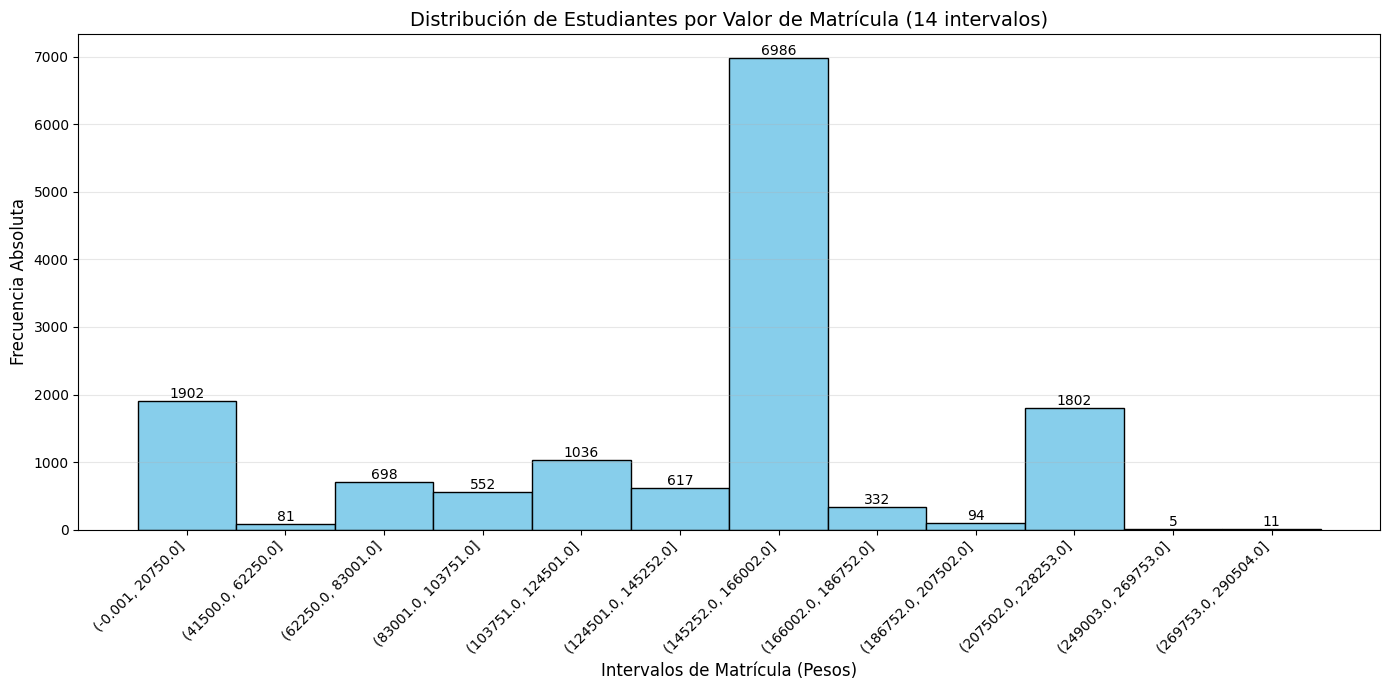

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('01_MATRICULAS_ED_SUPERIOR_ARICA_Y_PARINACOTA_2021.xlsx')

def sturges(n):
    return int(1 + 3.322 * np.log10(n))

df['MATRICULA'] = df['VALOR MATRICULA (PESOS)']

media = df['MATRICULA'].mean().round(2)
mediana = df['MATRICULA'].median()
moda = df['MATRICULA'].mode().iloc[0]

percentil_25 = df['MATRICULA'].quantile(0.25)
percentil_50 = df['MATRICULA'].quantile(0.50)
percentil_75 = df['MATRICULA'].quantile(0.75)

print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Moda: {moda}')
print(f'Percentil 25: {percentil_25}')
print(f'Percentil 50: {percentil_50}')
print(f'Percentil 75: {percentil_75}')

minimo = df['MATRICULA'].min()
maximo = df['MATRICULA'].max()
print(f'Matrícula mínima: {minimo}')
print(f'Matrícula máxima: {maximo}')

n = df.shape[0]
k = sturges(n)
print(f'\nNúmero de intervalos según Sturges: {k}')

minimo = int(df['MATRICULA'].min())
maximo = int(df['MATRICULA'].max())
limites = np.linspace(minimo, maximo, k + 1, dtype=int)
df['Intervalos'] = pd.cut(df['MATRICULA'], bins=limites, include_lowest=True)

frecuencia = df.groupby('Intervalos', observed=True).size()

tabla_continua = pd.DataFrame({
    'fi': frecuencia,
    'hi': (frecuencia/n)*100,
    'Fi': frecuencia.cumsum(),
    'Hi': ((frecuencia/n) * 100).cumsum()
})

print('\n--- Tabla de Frecuencias por Intervalos de Matrícula ---')
print(tabla_continua.round(2))

fig, ax = plt.subplots(figsize=(14, 7))
histograma = ax.bar(tabla_continua.index.astype(str), tabla_continua['fi'], color='skyblue', edgecolor='black', width=1)

ax.set_title(f'Distribución de Estudiantes por Valor de Matrícula ({k} intervalos)', fontsize=14)
ax.set_xlabel('Intervalos de Matrícula (Pesos)', fontsize=12)
ax.set_ylabel('Frecuencia Absoluta', fontsize=12)
ax.bar_label(histograma)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('01_MATRICULAS_ED_SUPERIOR_ARICA_Y_PARINACOTA_2021.xlsx')

num_bins = 15
edad_intervalos = pd.cut(df['EDAD'], bins=num_bins, precision=0, include_lowest=True)
df['RANGO_EDAD'] = edad_intervalos

tabla_contingencia = pd.crosstab(df['RANGO_EDAD'], df['TIPO DE INSTITUCION'])
print("\n--- Tabla de Contingencia: Edad vs Tipo de Institución ---")
print(tabla_contingencia)

porcentaje_fila = tabla_contingencia.div(tabla_contingencia.sum(axis=1), axis=0) * 100

tabla_frecuencia_completa = pd.DataFrame({
    'Rango de Edad': tabla_contingencia.index.astype(str),
    'Frecuencia Absoluta (fi)': tabla_contingencia.sum(axis=1).values,
    'Frecuencia Relativa (hi)': (tabla_contingencia.sum(axis=1) / len(df)).values,
    'Porcentaje (%)': ((tabla_contingencia.sum(axis=1) / len(df)) * 100).round(2).values,
    'Frecuencia Acumulada (Fi)': tabla_contingencia.sum(axis=1).cumsum().values,
    'Frecuencia Acumulada Relativa (Hi)': (tabla_contingencia.sum(axis=1).cumsum() / len(df)).values,
    'Porcentaje Acumulado (%)': ((tabla_contingencia.sum(axis=1).cumsum() / len(df)) * 100).round(2).values
})

print("\n--- Tabla de Frecuencias Completa por Rango de Edad ---")
print(tabla_frecuencia_completa.to_string(index=False))

plt.figure(figsize=(14, 8))
porcentaje_fila.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='viridis', edgecolor='black')
plt.title('Distribución de Tipo de Institución por Rango de Edad', fontsize=16)
plt.xlabel('Rango de Edad', fontsize=12)
plt.ylabel('Porcentaje de Estudiantes (%)', fontsize=12)
plt.legend(title='Tipo de Institución', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Análisis General


La edad sí influye significativamente en el tipo de institución de educación superior que eligen los estudiantes en la región de Arica y Parinacota. Se observan patrones claros y diferenciados según los rangos etarios.

Estudiantes jóvenes (17-26 años): Predominan en Universidades CRUCH.

Estudiantes de edad intermedia (26-45 años): Se observa un aumento progresivo en la elección de CFT.

Estudiantes adultos mayores (45+ años): Los CFT concentran el mayor porcentaje, seguido por las Universidades CRUCH.

Conclusion

Los estudiantes más jóvenes siguen la ruta tradicional hacia las universidades, mientras que los adultos mayores optan por instituciones más flexibles y prácticas como los CFT.